In [20]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')


Saving tcc_ceds_music.csv to tcc_ceds_music.csv
User uploaded file "tcc_ceds_music.csv" with length 27655251 bytes


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


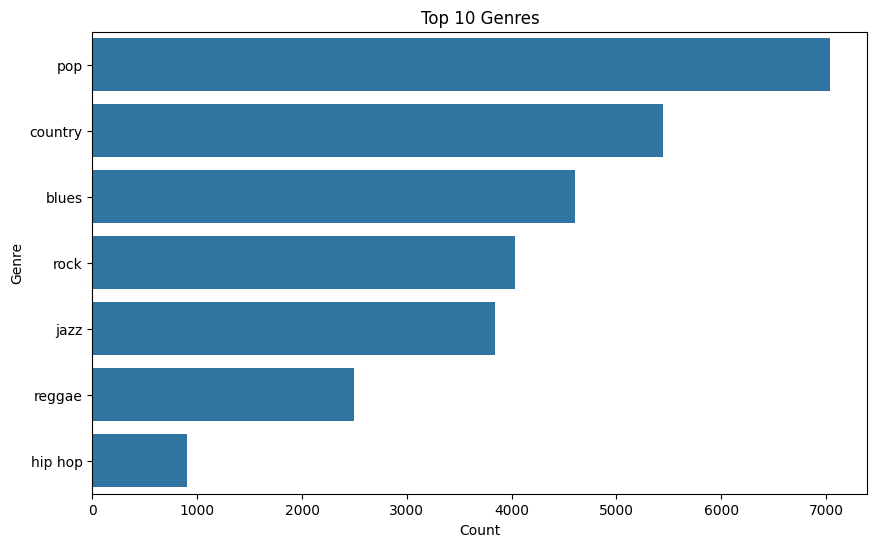

In [6]:
data = pd.read_csv('tcc_ceds_music.csv')
# Step 3: Exploratory Data Analysis (EDA)
# Distribution of Songs by Genre
plt.figure(figsize=(10, 6))
sns.countplot(y='genre', data=data, order=data['genre'].value_counts().index[:10])
plt.title('Top 10 Genres')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.show()

/tmp/ipykernel_1276/1097649183.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_artists.values, y=top_artists.index, palette='viridis')


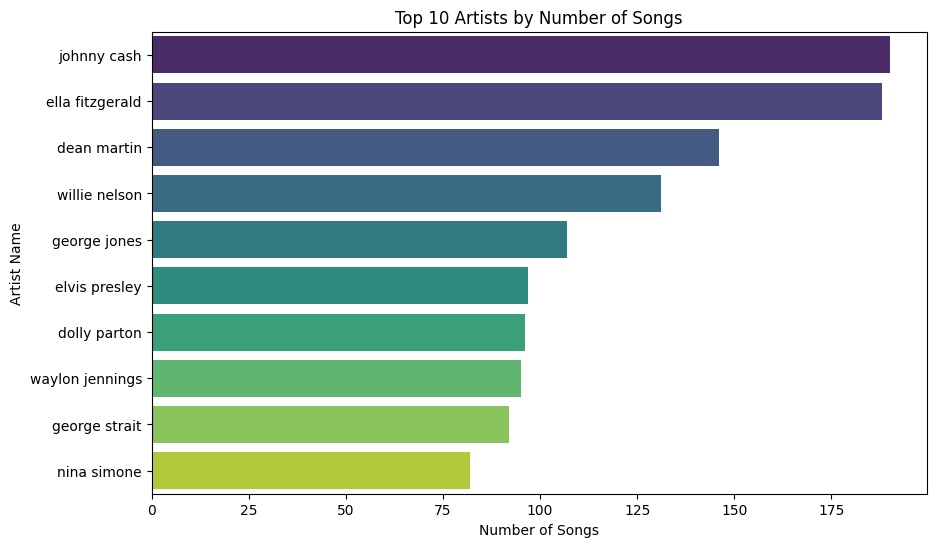

In [7]:
# Top Artists by Song Count
top_artists = data.groupby('artist_name').size().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_artists.values, y=top_artists.index, palette='viridis')
plt.title('Top 10 Artists by Number of Songs')
plt.xlabel('Number of Songs')
plt.ylabel('Artist Name')
plt.show()

In [8]:
# Step 4: Preprocessing the Data
# Combine song metadata into a single feature for similarity computation
data['combined_features'] = (
    data['genre'].fillna('') + ' ' +
    data['artist_name'].fillna('') + ' ' +
    data['track_name'].fillna('')
)


In [9]:
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(data['combined_features'])

In [10]:
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

# Step 5: Build the Recommendation Function
def get_recommendations(song_title, data, cosine_sim, top_n=10):
    # Get the index of the song that matches the title
    idx = data[data['track_name'] == song_title].index
    if len(idx) == 0:
        print("Song not found in the dataset.")
        return

    idx = idx[0]

    # Get similarity scores for all songs
    sim_scores = list(enumerate(cosine_sim[idx]))

    # Sort songs based on similarity scores
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Get top N most similar songs
    sim_scores = sim_scores[1:top_n+1]  # Exclude the song itself
    song_indices = [i[0] for i in sim_scores]

    # Return recommended songs
    recommendations = data.iloc[song_indices]
    return recommendations

In [21]:
recommended_songs = get_recommendations('hum tujhse mohabbat kar ke', data, cosine_sim, top_n=10)
print(recommended_songs[['track_name', 'artist_name', 'genre']])

                                track_name     artist_name    genre
0                     mohabbat bhi jhoothi          mukesh      pop
33                raat andheri door savera          mukesh      pop
27825                       ini illaye hum  hiphop tamizha  hip hop
1946                 zindagi ke safar mein   kishore kumar      pop
27500  ya ke'sto no es pop, es hip-hop/rap         frank t  hip hop
2656                       beyond and back               x      pop
2891                                   9-9          r.e.m.      pop
2277                          this is pop?             xtc      pop
4901                                   pop          *nsync      pop
2241                           without you           heart      pop


/tmp/ipykernel_1276/3606485217.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='track_name', x='artist_name', data=recommended_songs, palette='coolwarm')


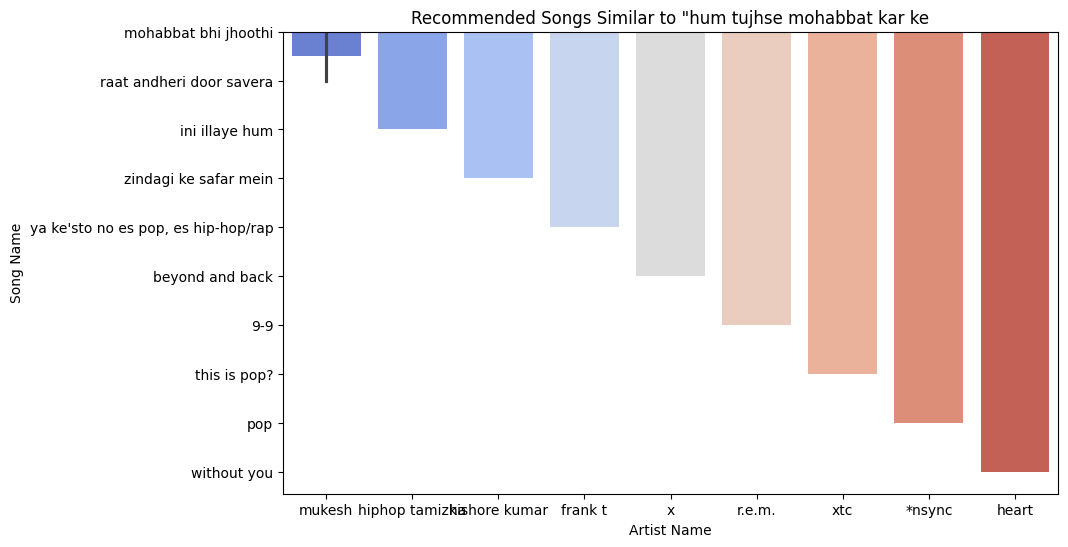

In [22]:
plt.figure(figsize=(10, 6))
sns.barplot(y='track_name', x='artist_name', data=recommended_songs, palette='coolwarm')
plt.title('Recommended Songs Similar to "hum tujhse mohabbat kar ke')
plt.xlabel('Artist Name')
plt.ylabel('Song Name')
plt.show()
